In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import ee
import geemap

In [3]:
try:
    ee.Initialize()
except:
    # need to authenticate with your credential at the first time
    ee.Authenticate()
    ee.Initialize()

In [4]:
def maskS2clouds(image):
    qa = image.select('QA60')
    neighbor_size = 30         # 30 pixels or 300 meters
    quality_threshold = 0.05   # above 5% of cloud or shadow would be masked
    
    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    
    # Both flags should be set to zero, indicating clear conditions.Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    
    """
    *  Account for shadow effect and use neighborhood average
    """
    # calculate the neighborhood average (NA) fraction of cloud (SCL 8-10)
    cldPrbNA = image.select('SCL').gte(8).And(image.select('SCL').lte(10)) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldPrbNA')
    
    # calculate the neighborhood average (NA) fraction of shadow (SCL 3)
    cldShadowNA = image.select('SCL').eq(3) \
        .reduceNeighborhood(**{
            'reducer': ee.Reducer.mean(),
            'kernel': ee.Kernel.circle(neighbor_size)
        }).rename('cldShadowNA')
    
    # the NA fraction of clouds and shadow
    cldTotalNA = cldPrbNA.add(cldShadowNA)
    
    # Update the mask, cldTotalNA should be lower than quality_threshold defined above
    mask = mask.And(cldTotalNA.lt(quality_threshold))
    return image.updateMask(mask).divide(10_000) \
        .addBands(cldPrbNA).addBands(cldShadowNA) \
        .copyProperties(image, ['system:time_start'])

In [5]:
def maskLSclouds(image):
    qa = image.select('QA_PIXEL')
    neighbor_size = 10              # 10 Pixels or 300 meters
    quality_threshold = 0.05        # above 5% of cloud or shadow would be masked
    
    # Bits 2, 3, and 4 are clouds, cirrus, and cloud shadow, respectively.
    cloudBitMask = 1 << 2
    cirrusBitMask = 1 << 3
    shadowBitMask = 1 << 4
    
    # Both flags should be set to zero, indicating clear conditions.Both flags should be set to zero, indicating clear conditions.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0)) \
      .And(qa.bitwiseAnd(shadowBitMask).eq(0))
    
    return image.updateMask(mask).select('SR_B.') \
                .multiply(0.0000275).add(-0.2) \
                .copyProperties(image, ['system:time_start'])

In [10]:
def addVegetationIndices(image, region):
    image = image.clip(region)
    
    NIRv = image.expression(
        '((NIR - RED) / (NIR + RED)) * NIR',
        { 
          'NIR': image.select('B8'),
          'RED': image.select('B4')
        }).rename('NIRv')
    
    EVI = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED + 7.5 * BLUE + 1))',
        {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    # Return the masked image with NIRv and EVI bands.
    return image.addBands(NIRv).addBands(EVI)

# Define Study Regions
Only run one of these cells

## Mt. Pleasant

In [7]:
MtPleasant = ee.Geometry.Polygon(
    [-76.39092979365925, 42.47111031803205,
     -76.39092979365925, 42.46458902246419,
     -76.37702522212605, 42.46458902246419,
     -76.37702522212605, 42.47111031803205], None, False)

def addVegetationIndices_MtPleasant(image):
    return addVegetationIndices(image, MtPleasant)

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices_MtPleasant).select(['EVI', 'NIRv'])

image_dir = '../images/images_MtPleasant'

In [21]:
MtPleasant = ee.Geometry.Polygon(
    [-76.39092979365925, 42.47111031803205,
     -76.39092979365925, 42.46458902246419,
     -76.37702522212605, 42.46458902246419,
     -76.37702522212605, 42.47111031803205], None, False)

def addVegetationIndices_MtPleasant(image):
    return addVegetationIndices(image, MtPleasant)

# Setup Landsat image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUD_COVER', 80)) \
    .map(maskLSclouds).map(addVegetationIndices_MtPleasant).select(['EVI', 'NIRv'])

image_dir = '../images/images_MtPleasant_L'

## Arnot Forest

In [ ]:
# Define study region 
ArnotForest = ee.Geometry.Polygon(
    [-76.635694, 42.287797,
     -76.615694, 42.287797, 
     -76.615694, 42.300797, 
     -76.635694, 42.300797],None, False);

def addVegetationIndices_ArnotForest(image):
    return addVegetationIndices(image, ArnotForest)

# Setup Sentinel-2 image collection over study region with low(ish) cloud cover
site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(ArnotForest) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices_ArnotForest).select(['EVI', 'NIRv'])

image_dir = '../images/images_ArnotForest'

## Turkey Hill

In [12]:
TurkeyHill1 = ee.Geometry.Polygon(
    [-76.420,42.448,
     -76.410,42.448, 
     -76.410,42.458, 
     -76.420,42.458],None, False)

def addVegetationIndices_TurkeyHill1(image):
    return addVegetationIndices(image, TurkeyHill1)

site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(TurkeyHill1) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices_TurkeyHill1).select(['EVI', 'NIRv'])

image_dir = '../images/images_TurkeyHill1'

In [12]:
TurkeyHill2 = ee.Geometry.Polygon(
    [-76.441,42.473,
     -76.431,42.473, 
     -76.431,42.478, 
     -76.441,42.478],None, False)

def addVegetationIndices_TurkeyHill2(image):
    return addVegetationIndices(image, TurkeyHill2)

site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(TurkeyHill1) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .map(maskS2clouds).map(addVegetationIndices_TurkeyHill2).select(['EVI', 'NIRv'])

image_dir = '../images/images_TurkeyHill2'

# Download data

In [13]:
# Download data
geemap.ee_export_image_collection(site_images, out_dir=image_dir)

Total number of images: 322

Exporting 1/322: 20181225T160659_20181225T160841_T18TUN.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\defoliation\DefoliationClassification\images\images_TurkeyHill1\20181225T160659_20181225T160841_T18TUN.tif


Exporting 2/322: 20181227T155651_20181227T155851_T18TUN.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\defoliation\DefoliationClassification\images\images_TurkeyHill1\20181227T155651_20181227T155851_T18TUN.tif


Exporting 3/322: 20190114T160619_20190114T160808_T18TUN.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\defoliation\DefoliationClassification\images\images_TurkeyHill1\20190114T160619_20190114T160808_T18TUN.tif


Exporting 4/322: 20190121T155549_20190121T155552_T18TUN.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\defoliation\DefoliationClassification\images\images_TurkeyHill1\20190121T155549_20190121T155552_T18TUN.tif


Exporting 5/322: 20

In [24]:
site_images = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUD_COVER', 80)) \
    .filterDate('2021-06-01', '2021-07-31') \
    .map(maskLSclouds).select(['SR_B4', 'SR_B3', 'SR_B2'])

'''site_images = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(MtPleasant) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80)) \
    .filterDate('2021-06-01', '2021-07-31').map(maskS2clouds).select(['B4', 'B3', 'B2'])'''
geemap.ee_export_image(site_images.median(), filename='../data/results_MtPleasant_L/study_area.tif', region=MtPleasant)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\camer\defoliation\DefoliationClassification\data\results_MtPleasant_L\study_area.tif


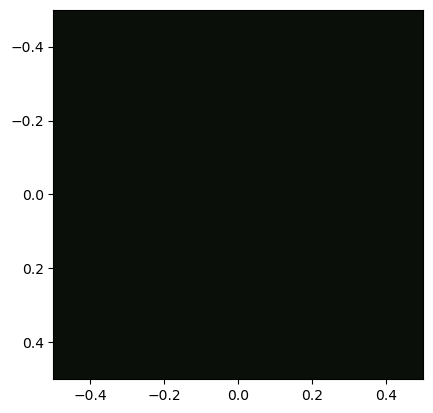

In [25]:
import rasterio
import numpy as np
import xarray as xr

with rasterio.open('../data/results_MtPleasant/study_area.tif', 'r') as src:
    im = src.read()
    # read image into ndarray

    # transpose the matrix from (band, row, col) to (row, col, band)
    im = np.transpose(im, [1,2,0])

    # set null values
    im[im == 0.] = np.nan

    # get coordinates
    # first axis, from north to south
    lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
    # second axis, from west to east
    lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

    src.close()
    
    da = xr.Dataset({'B4':(('lat','lon'),im[:,:,0]), 'B3':(('lat','lon'),im[:,:,1]), 'B2':(('lat','lon'),im[:,:,2])},
                     coords={'lat':lat_array,'lon':lon_array})
    

import matplotlib.pyplot as plt
plt.imshow(im)

In [26]:
da.to_dataframe()

,,B4,B3,B2
lat,lon,,,
43.0,-77.0,0.0401,0.0614,0.0391


In [28]:
import geemap
image = site_images.median().clip(MtPleasant)
Map = geemap.Map()
rgbVis = {
  'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
  'min': 0,
  'max': 0.2,
}
Map.addLayer(image, rgbVis, 'Sentinel-2 Image')
Map.centerObject(MtPleasant)
display(Map)

Map(center=[20, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=HBox(children=(Togg…